# Coding Assessment/Technical Exercise

Professors Schmidt, Choukhmane

MIT Sloan Finance Group – Technical Associate Position

Author: Stanley Gao

Date: Feb 8, 2026




In [79]:
# !uv add pandas
# !uv add numpy statsmodels matplotlib
# !uv add pandas-datareader
# !uv add fredapi
# !uv add openpyxl xlrd

# !pip3 install pandas numpy statsmodels matplotlib pandas-datareader fredapi openpyxl xlrd --break-system-packages

## Setup

In [ ]:
# Setup

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
# https://stackoverflow.com/questions/43545050/using-matplotlib-notebook-after-matplotlib-inline-in-jupyter-notebook-doesnt
# not sure if this is needed, but leaving in as works for me
%matplotlib inline
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## Load Data

### FRED (pandas_datareader) - not working

Had trouble getting datareader working on my system, found alternative (fredapi)

Skip this section

In [19]:
# from pandas_datareader import data as pdr

In [20]:
# series = ['CNP16OV', 'GDP', 'GDPDEF', 'HOANBS', 'PCE', 'PNFI']

# start = '1947-01-01' # first observation for most
# end = '2025-12-31'

# df = pdr.DataReader(series, 'fred', start, end)

# df.shape()
# df.head()

### FRED (fredapi)

Attempting using https://github.com/mortada/fredapi?tab=readme-ov-file 

https://pypi.org/project/fredapi/


In [ ]:
# from https://fredaccount.stlouisfed.org/apikeys
FRED_API_KEY = "6bcb1577a6e8811853f5b705e8440343"


from fredapi import Fred

# grab FRED data
series = ['CNP16OV', 'GDP', 'GDPDEF', 'HOANBS', 'PCE', 'PNFI']
data = pd.DataFrame()
for s in series:
    fred = Fred(api_key=FRED_API_KEY)
    data[s] = fred.get_series(s)

In [22]:
print(data.shape)
print(data.head())

(936, 6)
             CNP16OV      GDP  GDPDEF  HOANBS  PCE    PNFI
1948-01-01  102603.0  265.742  11.865  42.582  NaN  28.231
1948-02-01  102698.0      NaN     NaN     NaN  NaN     NaN
1948-03-01  102771.0      NaN     NaN     NaN  NaN     NaN
1948-04-01  102831.0  272.567  11.972  42.564  NaN  28.050
1948-05-01  102923.0      NaN     NaN     NaN  NaN     NaN


In [ ]:
# Resample to quarterly
# quarterly start (Q1 = Jan1, Q2 = Apr1) to match other data sources pulled in

fred_q = data.resample('QS').mean()

In [24]:
print(fred_q.shape)
print(fred_q.head())

(312, 6)
                  CNP16OV      GDP  GDPDEF  HOANBS  PCE    PNFI
1948-01-01  102690.666667  265.742  11.865  42.582  NaN  28.231
1948-04-01  102915.333333  272.567  11.972  42.564  NaN  28.050
1948-07-01  103249.000000  279.196  12.193  42.864  NaN  29.081
1948-10-01  103417.666667  280.366  12.230  42.471  NaN  30.160
1949-01-01  103584.333333  275.034  12.165  41.756  NaN  28.583


### Ford TFP

In [25]:
ford = pd.read_csv("data/ford_tfp.csv")
print(ford.shape)
print(ford.head())

(267, 2)
   quarter  ford_tfp
0  1949.00       NaN
1  1949.25  0.949670
2  1949.50  0.126885
3  1949.75 -1.130330
4  1950.00  1.099368


In [26]:
# convert quarterly .00, .25 etc. into two fields, year and quarter (1, 2, 3, 4) then put into a PeriodIndex
# https://pandas.pydata.org/docs/reference/api/pandas.PeriodIndex.html

ford_quarter = ford["quarter"]
year = np.floor(ford_quarter).astype(int)
quarter_frac = ford_quarter - year

quarter_int = np.floor(quarter_frac * 4 + 1).astype(int) # 0.25 -> 1, 0.5 -> 2, 0.75 -> 3, 1 -> 4

yr_quarter_str = year.astype(str) + 'Q' + quarter_int.astype(str) # 1948Q1, 1948Q2, etc

ford_q = pd.PeriodIndex(yr_quarter_str, freq='Q').to_timestamp()

ford["date"] = ford_q
ford = ford.set_index("date").sort_index()

ford_q = ford.copy()

In [27]:
# drop quarter
ford_q = ford_q.drop(columns=["quarter"])
print(ford_q.head())

            ford_tfp
date                
1949-01-01       NaN
1949-04-01  0.949670
1949-07-01  0.126885
1949-10-01 -1.130330
1950-01-01  1.099368


### Fernald TFP Shocks

In [ ]:
fernald = pd.read_excel("data/quarterly_tfp.xlsx", sheet_name="quarterly", header=1)

print(fernald.columns)

# row 2 is headers
# date: col A (1947:Q1)
# dtfp_util: col N (float)

# hardcoded drop to remove full sample mean, ranges
# NOTE: magic hardcode, this may change if data grows
# better solution would be to drop rows that do not fit the date format
fernald = fernald.iloc[:315].copy()

# print(fernald.head())
print(fernald.tail())

Index(['date', 'dY_prod', 'dY_inc', 'dY', 'dhours', 'dLP', 'dk',
       'dLQ_BLS_interpolated', 'dLQ_Aaronson_Sullivan', 'dLQ', 'alpha', 'dtfp',
       'dutil', 'dtfp_util', 'relativePrice', 'invShare', 'dtfp_I', 'dtfp_C',
       'du_invest', 'du_consumption', 'dtfp_I_util', 'dtfp_C_util'],
      dtype='object')
        date   dY_prod    dY_inc        dY    dhours       dLP        dk  \
310  2024:Q3  3.695275  1.819377  2.757326  1.128801  1.628525  2.814481   
311  2024:Q4  1.709369  4.061640  2.885505  0.322472  2.563033  2.765799   
312  2025:Q1 -1.113693  0.993158 -0.060268  1.102028 -1.162296  2.493172   
313  2025:Q2  5.014833  3.429091  4.221962  0.702802  3.519160  2.988542   
314  2025:Q3  5.335359  2.928536  4.131947  0.452766  3.679181  2.936626   

     dLQ_BLS_interpolated  dLQ_Aaronson_Sullivan       dLQ     alpha  \
310              0.412802               0.259439  0.259439  0.403172   
311              0.206241               1.437569  1.437569  0.403034   
312          

In [29]:
# remove the semicolons in date (1947:Q1 -> 1947Q1)
fernald["date"] = fernald["date"].str.replace(":", "", regex=False)

# use PeriodIndex
fernald["date"] = pd.PeriodIndex(fernald["date"], freq="Q").to_timestamp()

fernald = fernald.set_index("date").sort_index()

fernald_dtfp_util = fernald[["dtfp_util"]].copy()

In [30]:
print(fernald_dtfp_util.shape)
print(fernald_dtfp_util.head())

(315, 1)
            dtfp_util
date                 
1947-01-01        NaN
1947-04-01  -1.337761
1947-07-01   1.588308
1947-10-01  -1.746097
1948-01-01  12.104043


### Shiller shock price data

In [31]:
shiller = pd.read_excel("data/ie_data.xls", sheet_name="Data", header=7)

print(shiller.columns)

# headers are rows 1-8, not easily extractable
# "Date" is col A, S&P Comp.P is col B ("P" in row 8)

Index(['Date', 'P', 'D', 'E', 'CPI', 'Fraction', 'Rate GS10', 'Price',
       'Dividend', 'Price.1', 'Earnings', 'Earnings.1', 'CAPE', 'Unnamed: 13',
       'TR CAPE', 'Unnamed: 15', 'Yield', 'Returns', 'Returns.1',
       'Real Return', 'Real Return.1', 'Returns.2'],
      dtype='object')


In [32]:
# keep just date, P
shiller = shiller[["Date", "P"]]
shiller = shiller.rename(columns={"Date": "date", "P": "sp_comp_p"})

# cut last row (notes row)
shiller = shiller.iloc[:-1].copy()

print(shiller.shape)
print(shiller.head())
print(shiller.tail())

(1833, 2)
      date sp_comp_p
0  1871.01      4.44
1  1871.02       4.5
2  1871.03      4.61
3  1871.04      4.74
4  1871.05      4.86
         date    sp_comp_p
1828  2023.05  4146.173182
1829  2023.06  4345.372857
1830  2023.07    4508.0755
1831  2023.08  4457.358696
1832  2023.09      4515.77


In [33]:
# Date looks to be stored as YYYY.MM (as a float). Handle this

shiller_m = shiller["date"]
year = np.floor(shiller_m).astype(int)
month = np.floor((shiller_m - year) * 100 + 1).astype(int) # add the plus one, some reason 1949.01 -> month 0

# Build datetime index directly
shiller_dates = pd.to_datetime(
    dict(year=year, month=month, day=1)
)

shiller["realdate"] = shiller_dates

In [34]:
print(shiller.shape)
print(shiller.head())
print(shiller.tail())

(1833, 3)
      date sp_comp_p   realdate
0  1871.01      4.44 1871-01-01
1  1871.02       4.5 1871-02-01
2  1871.03      4.61 1871-03-01
3  1871.04      4.74 1871-04-01
4  1871.05      4.86 1871-05-01
         date    sp_comp_p   realdate
1828  2023.05  4146.173182 2023-05-01
1829  2023.06  4345.372857 2023-06-01
1830  2023.07    4508.0755 2023-07-01
1831  2023.08  4457.358696 2023-08-01
1832  2023.09      4515.77 2023-09-01


In [35]:
# find invalids
invalid_dates = shiller[shiller["realdate"].isna()]
print(invalid_dates)

Empty DataFrame
Columns: [date, sp_comp_p, realdate]
Index: []


In [36]:
# resample to quarterly

# use PeriodIndex
shiller["date"] = pd.PeriodIndex(shiller["realdate"], freq="Q").to_timestamp()
shiller = shiller.set_index("date").sort_index()

shiller_q = shiller[["sp_comp_p"]].resample("QS").mean()

In [37]:
print(shiller_q.shape)
print(shiller_q.head())
print(shiller_q.tail())

(611, 1)
           sp_comp_p
date                
1871-01-01  4.516667
1871-04-01  4.806667
1871-07-01  4.786667
1871-10-01  4.656667
1872-01-01  4.926667
              sp_comp_p
date                   
2022-07-01   3973.60434
2022-10-01  3851.973492
2023-01-01  4002.966789
2023-04-01  4204.337802
2023-07-01  4493.734732


## Check all loads

In [38]:
print(fred_q.shape)
print(fred_q.head())
print(fred_q.tail())
# 1948Q1-2025Q4 (2025Q4 has some missing values), PCE missing some

print(ford_q.shape)
print(ford_q.head())
print(ford_q.tail())
# 1949Q2-2009Q4. 1949Q1 NaN, 2010 through 2015Q3 missing tfp values

print(fernald_dtfp_util.shape)
print(fernald_dtfp_util.head())
print(fernald_dtfp_util.tail())
# 1947Q2-2025Q3, 1947Q1 NaN

print(shiller_q.shape)
print(shiller_q.head())
print(shiller_q.tail())
# 1871Q1-2023Q3

(312, 6)
                  CNP16OV      GDP  GDPDEF  HOANBS  PCE    PNFI
1948-01-01  102690.666667  265.742  11.865  42.582  NaN  28.231
1948-04-01  102915.333333  272.567  11.972  42.564  NaN  28.050
1948-07-01  103249.000000  279.196  12.193  42.864  NaN  29.081
1948-10-01  103417.666667  280.366  12.230  42.471  NaN  30.160
1949-01-01  103584.333333  275.034  12.165  41.756  NaN  28.583
                  CNP16OV        GDP   GDPDEF   HOANBS           PCE      PNFI
2024-10-01  269463.333333  29825.182  126.450  105.792  20351.300000  4046.390
2025-01-01  272851.666667  30042.113  127.577  106.112  20555.000000  4137.819
2025-04-01  273389.000000  30485.729  128.248  106.383  20789.933333  4207.512
2025-07-01  274004.000000  31098.027  129.430  106.503  21111.166667  4293.474
2025-10-01  274724.500000        NaN      NaN      NaN  21355.350000       NaN
(267, 1)
            ford_tfp
date                
1949-01-01       NaN
1949-04-01  0.949670
1949-07-01  0.126885
1949-10-01 -1.13033

In [39]:
# Check NAs

print("-----")
print(fred_q.shape)
print(fred_q.isna().sum())
print("-----")
print(ford_q.shape)
print(ford_q.isna().sum())
print("-----")
print(fernald_dtfp_util.shape)
print(fernald_dtfp_util.isna().sum())
print("-----")
print(shiller_q.shape)
print(shiller_q.isna().sum())
print("-----")

-----
(312, 6)
CNP16OV     0
GDP         1
GDPDEF      1
HOANBS      1
PCE        44
PNFI        1
dtype: int64
-----
(267, 1)
ford_tfp    24
dtype: int64
-----
(315, 1)
dtfp_util    1
dtype: int64
-----
(611, 1)
sp_comp_p    0
dtype: int64
-----


## Merge Data

Merge these datasets together into a single dataframe (i.e., using pandas) at quar-
terly frequency, taking means over variables to convert from monthly to quarterly
frequency as necessary (the resample function in pandas may be useful here).

In [40]:
df = fred_q.join([ford_q, fernald_dtfp_util, shiller_q], how="inner")

In [41]:
print(df.shape)
print(df.head())
print(df.tail())
# 1949Q1-2015Q3 (missing ford_tfp 2010-2015Q3)

(267, 9)
                  CNP16OV      GDP  GDPDEF  HOANBS  PCE    PNFI  ford_tfp  \
1949-01-01  103584.333333  275.034  12.165  41.756  NaN  28.583       NaN   
1949-04-01  103838.000000  271.351  12.043  41.068  NaN  27.476  0.949670   
1949-07-01  104127.333333  272.889  11.988  40.626  NaN  26.112  0.126885   
1949-10-01  104427.666667  270.627  11.989  40.452  NaN  25.628 -1.130330   
1950-01-01  104733.333333  280.828  11.970  40.769  NaN  26.386  1.099368   

            dtfp_util  sp_comp_p  
1949-01-01  -1.825655  15.013333  
1949-04-01   6.217348  14.546667  
1949-07-01   3.655195      15.18  
1949-10-01   0.115807      16.18  
1950-01-01   8.226685  17.146667  
                  CNP16OV        GDP  GDPDEF  HOANBS           PCE      PNFI  \
2014-07-01  248232.666667  17804.228  96.726  95.241  11959.833333  2465.578   
2014-10-01  248842.666667  17912.079  96.822  96.203  12081.566667  2492.333   
2015-01-01  249900.666667  18063.529  96.769  96.688  12119.800000  2497.171  

### Handle NaNs

In [42]:
# handle NaNs
print(df.isna().sum())

df = df.dropna(subset=["PCE", "ford_tfp"])

print("-----")
print(df.isna().sum())

CNP16OV       0
GDP           0
GDPDEF        0
HOANBS        0
PCE          40
PNFI          0
ford_tfp     24
dtfp_util     0
sp_comp_p     0
dtype: int64
-----
CNP16OV      0
GDP          0
GDPDEF       0
HOANBS       0
PCE          0
PNFI         0
ford_tfp     0
dtfp_util    0
sp_comp_p    0
dtype: int64


## Light renaming

In [43]:
df = df.rename(columns={"ford_tfp": "shock_ford", "dtfp_util": "shock_fernald"})

## Data Processing

### log real per-capita versions

For each variable in GDP, consumption, non-residential investment, and stock
prices (S&P Comp.P from the Shiller data), compute a log real per-capita version
by dividing through by population and the GDP deflator, and then taking logs.
Multiply each series by 100 so that it is expressed in percent.

SG: assuming using GDPDEF across the board to simplify (wouldn't we want a PCE deflator or CPI?)

In [44]:
# investigating issue with sp_comp_p
print(df[["sp_comp_p", "CNP16OV", "GDPDEF"]].dtypes)

# coerce to float
df["sp_comp_p"] = pd.to_numeric(df["sp_comp_p"], errors="coerce")

print(df[["sp_comp_p", "CNP16OV", "GDPDEF"]].dtypes)

sp_comp_p     object
CNP16OV      float64
GDPDEF       float64
dtype: object
sp_comp_p    float64
CNP16OV      float64
GDPDEF       float64
dtype: object


In [45]:
def log_real_per_capita(nominal, pop, deflator):
    real = nominal / deflator
    per_capita = real / pop
    log_per_capita = np.log(per_capita)
    pct_log_per_capita = 100 * log_per_capita
    return pct_log_per_capita

# lrpc = log real per capita
df["lrpc_gdp"]  = log_real_per_capita(df["GDP"],  df["CNP16OV"], df["GDPDEF"])
df["lrpc_cons"] = log_real_per_capita(df["PCE"],  df["CNP16OV"], df["GDPDEF"])
df["lrpc_inv"]  = log_real_per_capita(df["PNFI"], df["CNP16OV"], df["GDPDEF"]) # non-residential investment
df["lrpc_sp"]   = log_real_per_capita(df["sp_comp_p"], df["CNP16OV"], df["GDPDEF"]) # stock prices

### log hours per capita

Compute log hours per capita by dividing hours by population, taking logs, and
multiplying by 100.

In [46]:
hours_div_pop = df["HOANBS"] / df["CNP16OV"]
log_hours_div_pop = np.log(hours_div_pop)
pct_log_hours_div_pop = 100 * log_hours_div_pop

df["lpc_hours"] = pct_log_hours_div_pop

### log real labor productivity

Compute log real labor productivity by dividing GDP by hours and the GDP
deflator, taking logs, and multiplying by 100.

In [47]:
real_gdp = df["GDP"] / df["GDPDEF"]
real_labor_prod = real_gdp / df["HOANBS"]
log_real_labor_prod = np.log(real_labor_prod)
pct_log_real_labor_prod = 100 * log_real_labor_prod

df["lrpc_labor_prod"]  = pct_log_real_labor_prod

## Local Projection (regression)

The effects of the shocks, denoted ε, will be measured using local
projection regressions following Jord`
a (2005). Specifically, for each variable z and each
2
θh,jεt−j + γzt−1 + φ′
h Xt−1 + ut,t+h.
horizon h, run the linear regression
zt+h = αh +
2
∑
j=0
In words, this is a regression of the dependent variable z, h periods ahead (zt+h), on the
current value of the shock and two lags, the lagged value of the dependent variable
(zt−1) and on a vector of lagged control variables. The term ut,t+h is the regression
residual. Note that this regression must be run separately for each horizon of interest
h. Because the residuals ut,t+h span overlapping time periods, they are likely to be
serially correlated, so standard errors should be Newey-West corrected for h lags.1
Please run two sets of local projections varying the horizon from 0 to 20Q, one set
using the Fernald TFP shocks (dtfp util) and the other using the FORD TFP shocks,
as empirical proxies for {εt−j}2
j=0, respectively.
The rest of the specification is as follows.
1. For the dependent variables, {yt+h}20
h=0, use log real GDP per capita, log labor
productivity, log real stock prices per capita, log real consumption per capita,
log non-residential investment per capita.
2. For the controls, Xt−1, include log real GDP per capita, log real stock prices per
capita, log real labor productivity, and the dependent variable zt−1 (if it is not
one of the control variables already listed).

$z_{t+h} = \alpha_h + \sum_{j=0}^{2} \theta_{h,j} \varepsilon_{t-j} + \gamma z_{t-1} + \phi_h' X_{t-1} + u_{t,t+h}$

### Starting with one regression (getting this to work then will model the local projections across diff deps)

#### Setup

In [48]:
# dependent variables
dependent_vars = ["lrpc_gdp", "lrpc_labor_prod", "lrpc_sp", "lrpc_cons", "lrpc_inv"]
# shocks
shocks = ["shock_ford", "shock_fernald"]

# controls
controls = ["lrpc_gdp", "lrpc_sp", "lrpc_labor_prod"] # lag by 1 quarter
# note lrpc_cons and lrpc_inv are not included in regressions for the first 4 deps, but are included in last two
# aka, lrpc_cons as dep has lrpc_inv as control, and lrpc_inv as dep has lrpc_cons as control (this is it)
# SG economic interpretation: consumption and investment are components of GDP, cannot include them as controls (controlling for pieces of GDP)

In [49]:
# test pandas shift to confirm positive or negative direciton

test_df = pd.DataFrame({"x": ["a", "b", "c", "d", "e"]})

print(test_df)

print(test_df.shift(1))
print(test_df.shift(-1))

# we want to lag by 1 quarter, so need 1 (-1 would be future)

   x
0  a
1  b
2  c
3  d
4  e
      x
0  None
1     a
2     b
3     c
4     d
      x
0     b
1     c
2     d
3     e
4  None


In [50]:
dep = "lrpc_gdp"
shock = "shock_fernald"
h = 4

# dependent variable (z t+h)
y = df[dep].shift(-h)

# RHS pieces of regression

# shock terms
# note shift 1 -> t-1
epsilon_tm0 = df[shock]
epsilon_tm1 = df[shock].shift(1)
epsilon_tm2 = df[shock].shift(2)

# controls (X t-1)
X_tm1 = df[controls].shift(1)

# lagged dependent (z t-1)
# only needed if dependent variable is lrpc_cons or lrpc_inv
if dep in ["lrpc_cons", "lrpc_inv"]:
    z_tm1 = df[dep].shift(1)
else:
    z_tm1 = None

In [51]:
print(X_tm1.head())

              lrpc_gdp      lrpc_sp  lrpc_labor_prod
1959-01-01         NaN          NaN              NaN
1959-04-01 -813.801581 -1035.639011       -32.797729
1959-07-01 -811.942596 -1032.644284       -32.442704
1959-10-01 -812.231160 -1031.282396       -32.080768
1960-01-01 -812.262867 -1033.650647       -31.822577


In [52]:
# build dataframe
reg_df = pd.DataFrame(index=df.index)

# add dependent
reg_df[f"{dep}_tp{h}"] = y

# add shocks
reg_df[f"{shock}_tm0"] = epsilon_tm0
reg_df[f"{shock}_tm1"] = epsilon_tm1
reg_df[f"{shock}_tm2"] = epsilon_tm2

# add controls
for c in controls:
    if c != dep:
        reg_df[f"{c}_tm1"] = X_tm1[c]

# add lagged dependent
if z_tm1 is not None:
    reg_df[f"{dep}_l1"] = z_tm1

In [53]:
print(reg_df.shape)
print(reg_df.head())
print(reg_df.isna().sum())

(204, 6)
            lrpc_gdp_tp4  shock_fernald_tm0  shock_fernald_tm1  \
1959-01-01   -810.715069          -4.049210                NaN   
1959-04-01   -811.538413           0.062821          -4.049210   
1959-07-01   -811.367196           3.672289           0.062821   
1959-10-01   -813.010525           3.559791           3.672289   
1960-01-01   -812.704504           6.311564           3.559791   

            shock_fernald_tm2  lrpc_sp_tm1  lrpc_labor_prod_tm1  
1959-01-01                NaN          NaN                  NaN  
1959-04-01                NaN -1035.639011           -32.797729  
1959-07-01          -4.049210 -1032.644284           -32.442704  
1959-10-01           0.062821 -1031.282396           -32.080768  
1960-01-01           3.672289 -1033.650647           -31.822577  
lrpc_gdp_tp4           4
shock_fernald_tm0      0
shock_fernald_tm1      1
shock_fernald_tm2      2
lrpc_sp_tm1            1
lrpc_labor_prod_tm1    1
dtype: int64


In [54]:
# clean up NAs

reg_df = reg_df.dropna()
print(reg_df.shape)
print(reg_df.head())
print(reg_df.isna().sum())


(198, 6)
            lrpc_gdp_tp4  shock_fernald_tm0  shock_fernald_tm1  \
1959-07-01   -811.367196           3.672289           0.062821   
1959-10-01   -813.010525           3.559791           3.672289   
1960-01-01   -812.704504           6.311564           3.559791   
1960-04-01   -811.344159          -0.668744           6.311564   
1960-07-01   -809.748556           2.172184          -0.668744   

            shock_fernald_tm2  lrpc_sp_tm1  lrpc_labor_prod_tm1  
1959-07-01          -4.049210 -1032.644284           -32.442704  
1959-10-01           0.062821 -1031.282396           -32.080768  
1960-01-01           3.672289 -1033.650647           -31.822577  
1960-04-01           3.559791 -1037.333155           -30.221975  
1960-07-01           6.311564 -1038.235037           -30.929700  
lrpc_gdp_tp4           0
shock_fernald_tm0      0
shock_fernald_tm1      0
shock_fernald_tm2      0
lrpc_sp_tm1            0
lrpc_labor_prod_tm1    0
dtype: int64


#### Run regression

In [55]:
# setup formula
lhs = f"{dep}_tp{h}"
rhs_vars = [col for col in reg_df.columns if col != lhs]
formula = f"{lhs} ~ " + " + ".join(rhs_vars)
print(formula)

lrpc_gdp_tp4 ~ shock_fernald_tm0 + shock_fernald_tm1 + shock_fernald_tm2 + lrpc_sp_tm1 + lrpc_labor_prod_tm1


In [56]:
# run it
res_ols = smf.ols(formula, data=reg_df).fit()
res_hac = res_ols.get_robustcov_results(cov_type="HAC", maxlags=h)

In [57]:
# summary

print(res_hac.summary())

                            OLS Regression Results                            
Dep. Variable:           lrpc_gdp_tp4   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     501.8
Date:                Sun, 08 Feb 2026   Prob (F-statistic):          3.82e-108
Time:                        14:56:57   Log-Likelihood:                -532.21
No. Observations:                 198   AIC:                             1076.
Df Residuals:                     192   BIC:                             1096.
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            -721.2972    

In [58]:
# pull out results (shock)
# https://www.statsmodels.org/dev/generated/statsmodels.regression.linear_model.RegressionResults.html#statsmodels.regression.linear_model.RegressionResults

# print(res_ols.params)
# print(res_hac.params)
# type(res_ols.params)
# type(res_hac.params)

# res_hac is ndarray while res_ols is Series, need to transfer over index names by converting to Series

res_hac_params = pd.Series(res_hac.params, index=res_ols.params.index)
res_hac_bse = pd.Series(res_hac.bse, index=res_ols.params.index)

shock_col = f"{shock}_tm0"
theta_h = res_hac_params[shock_col]
theta_h_se = res_hac_bse[shock_col]
print(theta_h)
print(theta_h_se)


0.18988053956436346
0.07211052231065657


## Run local projection for one dep (across all horizons)

In [59]:
# for each horizon, run regression
# same logic as above (in the one regression only section, just wrapped in a function)

def local_projection(df, dep, shock, controls, H=20):

    out = []
    horizons = range(H + 1)

    for h in horizons:

        # build dataframe
        reg_df = pd.DataFrame(index=df.index)

        # add dependent
        y = df[dep].shift(-h)
        reg_df[f"{dep}_tp{h}"] = y

        # add shocks
        epsilon_tm0 = df[shock]
        epsilon_tm1 = df[shock].shift(1)
        epsilon_tm2 = df[shock].shift(2)
        reg_df[f"{shock}_tm0"] = epsilon_tm0
        reg_df[f"{shock}_tm1"] = epsilon_tm1
        reg_df[f"{shock}_tm2"] = epsilon_tm2

        # add controls
        X_tm1 = df[controls].shift(1)
        for c in controls:
            if c != dep:
                reg_df[f"{c}_tm1"] = X_tm1[c]

        # add lagged dependent (only if dependent variable is lrpc_cons or lrpc_inv)
        # NOTE: hardcoded these
        if dep in ["lrpc_cons", "lrpc_inv"]:
            z_tm1 = df[dep].shift(1)
            reg_df[f"{dep}_l1"] = z_tm1

        # clean up NAs
        reg_df = reg_df.dropna()

        # setup formula
        lhs = f"{dep}_tp{h}"
        rhs_vars = [col for col in reg_df.columns if col != lhs]
        formula = f"{lhs} ~ " + " + ".join(rhs_vars)

        # run it
        res_ols = smf.ols(formula, data=reg_df).fit()
        res_hac = res_ols.get_robustcov_results(cov_type="HAC", maxlags=h)

        # pull out results (shock)
        res_hac_params = pd.Series(res_hac.params, index=res_ols.params.index)
        res_hac_bse = pd.Series(res_hac.bse, index=res_ols.params.index)

        shock_col = f"{shock}_tm0"
        theta_h = res_hac_params[shock_col]
        theta_h_se = res_hac_bse[shock_col]

        # add to output
        out.append({
            "h": h,
            "theta": float(theta_h),
            "se": float(theta_h_se),
            "n": int(res_ols.nobs) # to check (expect to decline as h increases given shifting)
        })

    return pd.DataFrame(out)

# run it
res = local_projection(df, dep, shock, controls)
print(res)

     h     theta        se    n
0    0  0.074740  0.074459  202
1    1  0.044335  0.079440  201
2    2  0.075103  0.082293  200
3    3  0.160227  0.066739  199
4    4  0.189881  0.072111  198
5    5  0.200496  0.080828  197
6    6  0.238641  0.088368  196
7    7  0.233746  0.087897  195
8    8  0.206390  0.076441  194
9    9  0.245132  0.083810  193
10  10  0.228655  0.081947  192
11  11  0.191220  0.079344  191
12  12  0.174985  0.078766  190
13  13  0.169138  0.082937  189
14  14  0.125199  0.072933  188
15  15  0.052533  0.064583  187
16  16  0.047660  0.066204  186
17  17 -0.001617  0.063068  185
18  18 -0.017887  0.070497  184
19  19 -0.045687  0.071199  183
20  20 -0.056341  0.063156  182


## Run local projection for all deps, both shocks

In [60]:
# Restate from setup

# dependent variables
dependent_vars = ["lrpc_gdp", "lrpc_labor_prod", "lrpc_sp", "lrpc_cons", "lrpc_inv"]
# shocks
shocks = ["shock_ford", "shock_fernald"]

# controls
controls = ["lrpc_gdp", "lrpc_sp", "lrpc_labor_prod"] # lag by 1 quarter
# note lrpc_cons and lrpc_inv are not included in regressions for the first 4 deps, but are included in last two
# aka, lrpc_cons as dep has lrpc_inv as control, and lrpc_inv as dep has lrpc_cons as control (this is it)
# SG economic interpretation: consumption and investment are components of GDP, cannot include them as controls (controlling for pieces of GDP)

In [61]:
H = 20

out = []

for shock in shocks:
    for dep in dependent_vars:
        print(f"Running local projection for {dep} with {shock} shock")
        proj = local_projection(df, dep, shock, controls, H=H)

        # attach the shock, dep used for this projection
        proj = proj.copy()
        proj["dep"] = dep
        proj["shock"] = shock
        out.append(proj)

out = pd.concat(out)


Running local projection for lrpc_gdp with shock_ford shock
Running local projection for lrpc_labor_prod with shock_ford shock
Running local projection for lrpc_sp with shock_ford shock
Running local projection for lrpc_cons with shock_ford shock
Running local projection for lrpc_inv with shock_ford shock
Running local projection for lrpc_gdp with shock_fernald shock
Running local projection for lrpc_labor_prod with shock_fernald shock
Running local projection for lrpc_sp with shock_fernald shock
Running local projection for lrpc_cons with shock_fernald shock
Running local projection for lrpc_inv with shock_fernald shock


In [62]:
print(out.shape)
print(out.head())
print(out.tail())
print(out.isna().sum())

# 2 shocks, 5 deps, 21 horizons (0 through 20) -> 200 rows


(210, 6)
   h     theta        se    n       dep       shock
0  0  0.194975  0.231778  202  lrpc_gdp  shock_ford
1  1  0.270629  0.248144  201  lrpc_gdp  shock_ford
2  2  0.491409  0.234741  200  lrpc_gdp  shock_ford
3  3  0.636302  0.240824  199  lrpc_gdp  shock_ford
4  4  0.746894  0.267256  198  lrpc_gdp  shock_ford
     h     theta        se    n       dep          shock
16  16 -0.037897  0.115343  186  lrpc_inv  shock_fernald
17  17 -0.116608  0.114116  185  lrpc_inv  shock_fernald
18  18 -0.170652  0.139093  184  lrpc_inv  shock_fernald
19  19 -0.217243  0.152125  183  lrpc_inv  shock_fernald
20  20 -0.255247  0.128935  182  lrpc_inv  shock_fernald
h        0
theta    0
se       0
n        0
dep      0
shock    0
dtype: int64


## Plotting

Please report your results for each set of regressions in the form of a plot.
The plot should contain subplots showing the estimated response of each dependent
variable to the current shock εt, denoted θh,0 in the regression, where the x-axis is
the horizon h. The plots should also include 66.7% confidence bands around these
estimates.2

In [63]:
# to fix import issue?

# https://stackoverflow.com/questions/60302645/attributeerror-module-matplotlib-has-no-attribute-interactive
# !uv pip install --upgrade matplotlib

import matplotlib

In [70]:
# X-axis: h
# Y-axis: theta_h,0 (shock response/projection)
# add 66.7% confidence bands (1 SE)

fernald = out[out["shock"] == "shock_fernald"].copy()
print(fernald.shape)
print(fernald.groupby("dep")["h"].count())

print("-----")

ford = out[out["shock"] == "shock_ford"].copy()
print(ford.shape)
print(ford.groupby("dep")["h"].count())

(105, 6)
dep
lrpc_cons          21
lrpc_gdp           21
lrpc_inv           21
lrpc_labor_prod    21
lrpc_sp            21
Name: h, dtype: int64
-----
(105, 6)
dep
lrpc_cons          21
lrpc_gdp           21
lrpc_inv           21
lrpc_labor_prod    21
lrpc_sp            21
Name: h, dtype: int64


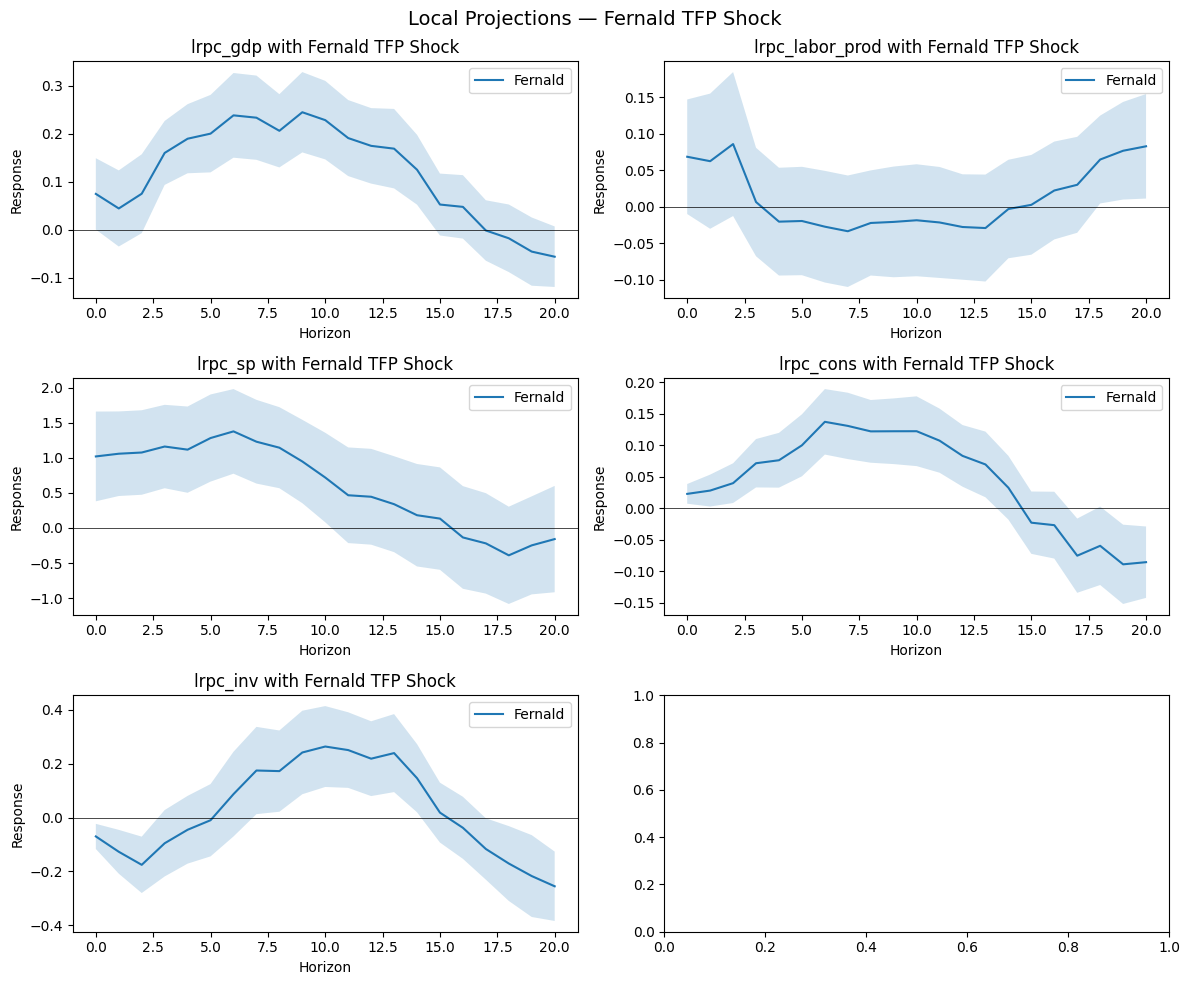

In [78]:
# deps to plot
dep_order = [
    "lrpc_gdp",
    "lrpc_labor_prod",
    "lrpc_sp",
    "lrpc_cons",
    "lrpc_inv"
]

# subplots, 3x2
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

# plot each dep
for i, dep in enumerate(dep_order):
    ax = axes[i]
    fernald_dep = fernald[fernald["dep"] == dep].copy()
    ax.plot(fernald_dep["h"], fernald_dep["theta"], label="Fernald")

    # plot 66.7% confidence bands
    ax.fill_between(
        fernald_dep["h"],
        fernald_dep["theta"] - fernald_dep["se"],
        fernald_dep["theta"] + fernald_dep["se"],
        alpha=0.2
    )

    # add zeroline
    ax.axhline(0, color="black", linewidth=0.5)

    # set things
    ax.set_title(f"{dep} with Fernald TFP Shock")
    ax.set_xlabel("Horizon")
    ax.set_ylabel("Response")
    ax.legend()



fig.suptitle("Local Projections — Fernald TFP Shock", fontsize=14)
plt.tight_layout()
plt.show()

# save
fig.savefig("output/local_projections_fernald.png")

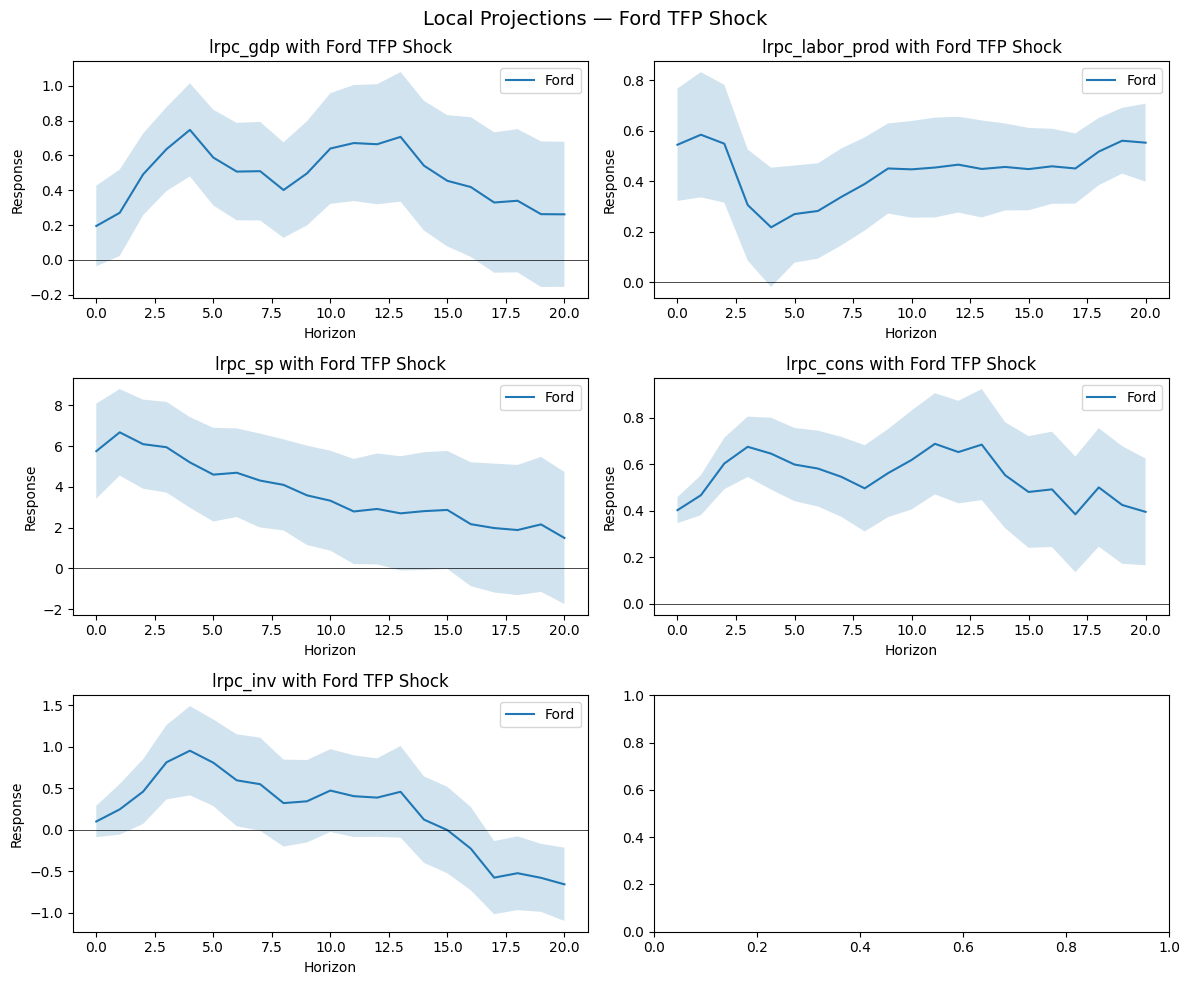

In [77]:
# deps to plot
dep_order = [
    "lrpc_gdp",
    "lrpc_labor_prod",
    "lrpc_sp",
    "lrpc_cons",
    "lrpc_inv"
]

# subplots, 3x2
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

# plot each dep
for i, dep in enumerate(dep_order):
    ax = axes[i]
    ford_dep = ford[ford["dep"] == dep].copy()
    ax.plot(ford_dep["h"], ford_dep["theta"], label="Ford")

    # plot 66.7% confidence bands
    ax.fill_between(
        ford_dep["h"],
        ford_dep["theta"] - ford_dep["se"],
        ford_dep["theta"] + ford_dep["se"],
        alpha=0.2
    )

    # add zeroline
    ax.axhline(0, color="black", linewidth=0.5)

    # set things
    ax.set_title(f"{dep} with Ford TFP Shock")
    ax.set_xlabel("Horizon")
    ax.set_ylabel("Response")
    ax.legend()



fig.suptitle("Local Projections — Ford TFP Shock", fontsize=14)
plt.tight_layout()
plt.show()

# save
fig.savefig("output/local_projections_ford.png")

## Economic Interpretation

Please write a short paragraph describing the economic
interpretation of the estimated local projection impulse responses. What do the figures
tell you about the relationship between TFP shocks and real GDP? (You can include
this paragraph at the end of your README file.)

We see that positive TFP shocks are followed by increases in real per capita GDP under both Fernald and Ford shock measures. For the Fernald shocks (utilization adjusted), real GDP rises in a hump pattern, peaking around 7.5-10 quarters after the shock, and returning towards baseline by ~17.5 quarters. The Fernald shock peaks at ~0.2 log real per capita GDP, implying a ~0.2% increase to real GDP per capita in that quarter compared to a no-shock path. The Ford shocks produce a larger, more persistent increase to GDP, with peaks around 5 and 12.5 quarters post-shock (at ~0.6 -> ~0.6% increase vs. no-shock path), and sustained above-zero gain through the 20 horizon analysis threshold. Overall, the figures support a positive relationship between TFP shocks and short/medium run effects to real per capita GDP.